In [1]:
# %pip install boto3
# %pip install "transformers==4.49.0"
# %pip install 'accelerate>=0.26.0'
# %pip install --upgrade --force-reinstall "boto3==1.42.84 " "botocore==1.42.84"
# %pip install s3fs
# %pip install sagemaker
# %pip install datasets


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
import boto3
import botocore
import json
import shutil
from typing import Any, NoReturn, Literal
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments)
from datasets import Dataset, DatasetDict


import warnings
warnings.filterwarnings(action="ignore")

### 1. Load & Explore Dataset

In [2]:
import s3fs
fs = s3fs.S3FileSystem()
df = pd.read_csv(filepath_or_buffer="s3://retention-engine-bucket/data/call_transcripts.csv", storage_options={"anon": False}, sep=",", engine="python", encoding="utf-8", encoding_errors="strict")
df

,call_id,customer_id,call_date,call_time,agent_id,agent_name,primary_scenario,call_transcript,overall_rating,call_successful,customer_monthly_spend,customer_service_count,customer_issue_history
0,CALL_000001,C00077940,2025-04-26,12:08,agent_005,Lisa Wang,payment_assistance,**Call Transcript**\n\n**Date:** 2025-04-26\n*...,5,True,173,2,18
1,CALL_000002,C00050897,2025-01-31,14:51,agent_007,Jennifer Davis,billing_inquiry,**Call Transcript**\n\n**Date:** 2025-01-31\n*...,5,True,182,2,0
2,CALL_000003,C00062906,2025-08-26,16:46,agent_008,Robert Kim,contract_renewal,**TriLink Telecom Customer Service Call Transc...,5,False,176,2,0
3,CALL_000004,C00077227,2025-06-13,17:59,agent_006,Michael Brown,technical_support,**Call Transcript: TriLink Telecom Customer Se...,7,True,100,1,3
4,CALL_000005,C00012668,2025-08-13,11:40,agent_004,James Thompson,cross_sell_security,**TriLink Telecom Customer Service Call Transc...,4,False,36,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,CALL_002496,C00031825,2025-06-23,12:19,agent_006,Michael Brown,technical_support,**TriLink Telecom Customer Service Call Transc...,7,True,366,3,8
2496,CALL_002497,C00050107,2025-01-02,10:18,agent_010,Carlos Martinez,complaint_resolution,**Call Transcript**\n\n**Date:** 2025-01-02\n*...,5,False,52,1,0
2497,CALL_002498,C00071410,2025-08-23,09:44,agent_010,Carlos Martinez,complaint_resolution,**CALL TRANSCRIPT**\n\n**Date:** 2025-08-23\n*...,6,True,202,2,3
2498,CALL_002499,C00069322,2025-01-14,16:22,agent_009,Ashley Johnson,service_cancellation,**TriLink Telecom Customer Service Call Transc...,6,False,323,3,0


In [3]:
# Explore data
print(f"Customer data: {df.shape[0]} rows, {df.shape[1]} columns")

Customer data: 2500 rows, 13 columns


In [4]:
print("--- Customer Data ---")
df.head(n=10)

--- Customer Data ---


,call_id,customer_id,call_date,call_time,agent_id,agent_name,primary_scenario,call_transcript,overall_rating,call_successful,customer_monthly_spend,customer_service_count,customer_issue_history
0,CALL_000001,C00077940,2025-04-26,12:08,agent_005,Lisa Wang,payment_assistance,**Call Transcript**\n\n**Date:** 2025-04-26\n*...,5,True,173,2,18
1,CALL_000002,C00050897,2025-01-31,14:51,agent_007,Jennifer Davis,billing_inquiry,**Call Transcript**\n\n**Date:** 2025-01-31\n*...,5,True,182,2,0
2,CALL_000003,C00062906,2025-08-26,16:46,agent_008,Robert Kim,contract_renewal,**TriLink Telecom Customer Service Call Transc...,5,False,176,2,0
3,CALL_000004,C00077227,2025-06-13,17:59,agent_006,Michael Brown,technical_support,**Call Transcript: TriLink Telecom Customer Se...,7,True,100,1,3
4,CALL_000005,C00012668,2025-08-13,11:40,agent_004,James Thompson,cross_sell_security,**TriLink Telecom Customer Service Call Transc...,4,False,36,1,3
5,CALL_000006,C00005383,2025-06-23,11:55,agent_010,Carlos Martinez,complaint_resolution,**TriLink Telecom Customer Service Call Transc...,7,True,394,3,7
6,CALL_000007,C00072547,2025-02-15,08:34,agent_003,Maria Rodriguez,billing_inquiry,**TriLink Telecom Customer Service Call Transc...,6,True,52,1,1
7,CALL_000008,C00084129,2025-04-10,08:21,agent_002,David Chen,technical_support,**Call Transcript**\n\n**Date:** 2025-04-10\n*...,7,True,47,1,0
8,CALL_000009,C00064140,2025-04-04,11:21,agent_006,Michael Brown,technical_support,**TriLink Telecom Customer Service Transcript*...,4,False,152,1,0
9,CALL_000010,C00002870,2025-07-17,11:17,agent_009,Ashley Johnson,cross_sell_internet,**TriLink Telecom Customer Service Call Transc...,7,True,260,2,9


In [5]:
print("--- Customer Data ---")
df.sample(n=10, random_state=3)

--- Customer Data ---


,call_id,customer_id,call_date,call_time,agent_id,agent_name,primary_scenario,call_transcript,overall_rating,call_successful,customer_monthly_spend,customer_service_count,customer_issue_history
1015,CALL_001016,C00096341,2025-07-15,14:48,agent_003,Maria Rodriguez,billing_inquiry,**TriLink Telecom Customer Service Call Transc...,4,False,63,1,8
972,CALL_000973,C00090738,2025-06-02,11:45,agent_002,David Chen,technical_support,**Call Transcript: TriLink Telecom Customer Se...,7,True,185,3,9
2178,CALL_002179,C00013093,2025-01-19,15:08,agent_006,Michael Brown,technical_support,**(Call begins with a standard automated greet...,5,False,53,1,6
2381,CALL_002382,C00022969,2025-08-08,15:26,agent_009,Ashley Johnson,cross_sell_mobile,**Call Transcript**\n\n**Date:** 2025-08-08\n*...,6,True,65,1,10
1797,CALL_001798,C00021010,2025-04-28,15:32,agent_007,Jennifer Davis,upsell_security_devices,**TriLink Telecom Customer Service Call Transc...,5,True,270,3,13
319,CALL_000320,C00055616,2025-08-18,15:11,agent_002,David Chen,payment_assistance,**Call Transcript**\n\n**Date:** 2025-08-18\n*...,5,True,108,2,19
1458,CALL_001459,C00069954,2025-06-01,10:45,agent_004,James Thompson,service_cancellation,**TriLink Telecom Customer Service Call Transc...,6,False,117,1,10
1363,CALL_001364,C00049079,2025-05-26,08:34,agent_009,Ashley Johnson,service_cancellation,**Date:** 2025-05-26\n**Agent:** Ashley Johnso...,7,True,377,2,2
1057,CALL_001058,C00047482,2025-01-03,08:44,agent_003,Maria Rodriguez,billing_inquiry,**Call Transcript: TriLink Telecom Customer Se...,6,True,334,3,1
334,CALL_000335,C00043068,2025-05-31,12:18,agent_006,Michael Brown,technical_support,**TriLink Telecom Customer Service Call Transc...,7,True,211,2,1


In [6]:
print("--- Customer Data Info ---")
df.info()

--- Customer Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   call_id                 2500 non-null   object
 1   customer_id             2500 non-null   object
 2   call_date               2500 non-null   object
 3   call_time               2500 non-null   object
 4   agent_id                2500 non-null   object
 5   agent_name              2500 non-null   object
 6   primary_scenario        2500 non-null   object
 7   call_transcript         2500 non-null   object
 8   overall_rating          2500 non-null   int64 
 9   call_successful         2500 non-null   bool  
 10  customer_monthly_spend  2500 non-null   int64 
 11  customer_service_count  2500 non-null   int64 
 12  customer_issue_history  2500 non-null   int64 
dtypes: bool(1), int64(4), object(8)
memory usage: 236.9+ KB


In [7]:
print('--- Customer Data Unique Types Count---')
df.select_dtypes(include="object").nunique()

--- Customer Data Unique Types Count---


call_id             2500
customer_id         2000
call_date            244
call_time            592
agent_id              10
agent_name            10
primary_scenario      14
call_transcript     2500
dtype: int64

In [8]:
print('---- Customer Data Unique Values')
unique_value = df.copy().drop(labels=['call_id', 'customer_id', 'call_date', 'agent_id', 'call_transcript', 'call_successful'], axis=1)
unique_value

---- Customer Data Unique Values


,call_time,agent_name,primary_scenario,overall_rating,customer_monthly_spend,customer_service_count,customer_issue_history
0,12:08,Lisa Wang,payment_assistance,5,173,2,18
1,14:51,Jennifer Davis,billing_inquiry,5,182,2,0
2,16:46,Robert Kim,contract_renewal,5,176,2,0
3,17:59,Michael Brown,technical_support,7,100,1,3
4,11:40,James Thompson,cross_sell_security,4,36,1,3
...,...,...,...,...,...,...,...
2495,12:19,Michael Brown,technical_support,7,366,3,8
2496,10:18,Carlos Martinez,complaint_resolution,5,52,1,0
2497,09:44,Carlos Martinez,complaint_resolution,6,202,2,3
2498,16:22,Ashley Johnson,service_cancellation,6,323,3,0


In [9]:
# Check for null values
print('--- Customer Data Null ---')
print(df.isnull().sum())
print()
print('--- Customer Data Sum Non Null ---')
print(df.notnull().value_counts().sum())

--- Customer Data Null ---
call_id                   0
customer_id               0
call_date                 0
call_time                 0
agent_id                  0
agent_name                0
primary_scenario          0
call_transcript           0
overall_rating            0
call_successful           0
customer_monthly_spend    0
customer_service_count    0
customer_issue_history    0
dtype: int64

--- Customer Data Sum Non Null ---
2500


In [10]:
print('--- Customer Data Statistics---')
df.describe()

--- Customer Data Statistics---


,overall_rating,customer_monthly_spend,customer_service_count,customer_issue_history
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,5.834000,208.087200,2.028800,4.152800
std,0.964373,128.998527,0.767467,4.308512
min,3.000000,12.000000,1.000000,0.000000
25%,5.000000,99.000000,1.000000,1.000000
50%,6.000000,187.500000,2.000000,3.000000
75%,6.000000,305.250000,3.000000,6.000000
max,8.000000,646.000000,3.000000,27.000000


In [11]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

df["call_successful"] = df["call_successful"].astype(dtype=int)

corr = df[numeric_cols].corr()
corr

,overall_rating,customer_monthly_spend,customer_service_count,customer_issue_history
overall_rating,1.000000,0.091115,0.057285,-0.151645
customer_monthly_spend,0.091115,1.000000,0.772061,-0.076734
customer_service_count,0.057285,0.772061,1.000000,0.142558
customer_issue_history,-0.151645,-0.076734,0.142558,1.000000


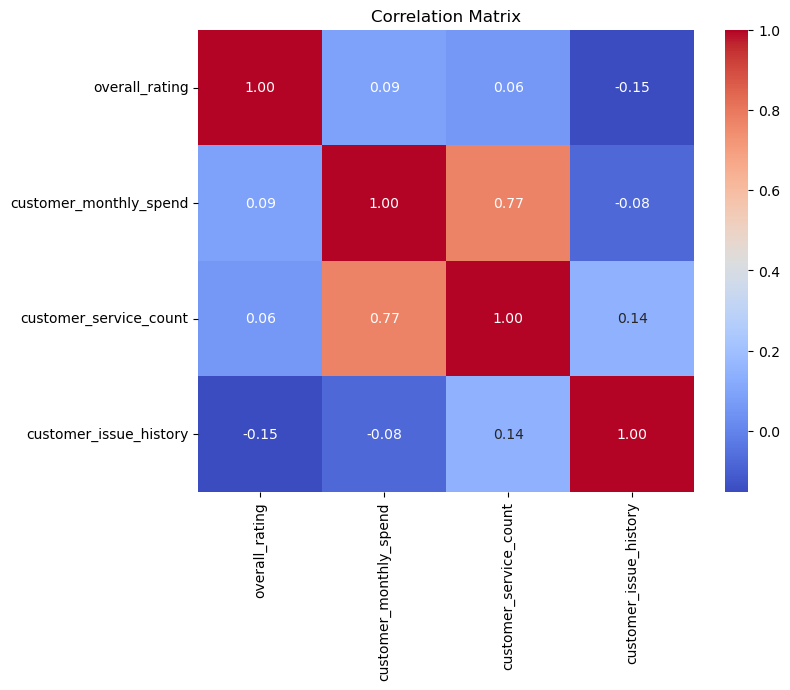

In [12]:

plt.figure(figsize=(8, 6))
sns.heatmap(data=corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title(label="Correlation Matrix")
plt.show()


In [13]:
# Save the feature order for the FastAPI wrapper
with open(file='feature_columns.json', mode='w') as f:
    json.dump(obj=df.columns.tolist(), fp=f)
print('Feature columns saved to feature_columns.json')

Feature columns saved to feature_columns.json


### 2. Feature Engineering & Preprocessing

In [14]:
import re

def sanitize_transcript(text) -> str | None | Literal['']:
    if pd.isna(text):
        return ""
    # Remove everything before the first '---'
    if "---" in text:
        text = text.split("---", 1)[1]
    # Remove **bold markdown**
    text = re.sub(pattern=r"\*\*(.*?)\*\*", repl="", string=text)
    # Remove (parentheses content)
    text = re.sub(pattern=r"\([^)]*\)", repl="", string=text)
    # Remove [bracket content]
    text = re.sub(pattern=r"\[[^\] ]*\]", repl="", string=text)
    # Normalize whitespace
    text = re.sub(pattern=r"\s+", repl=" ", string=text).strip()

    return text

df["clean_transcript"] = df["call_transcript"].apply(func=sanitize_transcript)
df["clean_transcript"].iloc[0][:100]

'Thank you for calling TriLink Telecom, my name is Lisa, how can I help you today? Yeah, hi Lisa. Um,'

In [15]:
def engineer_features(df) -> Any:
    df = df.copy()
    df["word_count"] = df["call_transcript"].str.split().str.len()
    df["avg_word_length"] = (
        df["call_transcript"]
        .str.split()
        .apply(lambda words: sum(len(w) for w in words) / len(words) if words else 0)
    )
    df["num_exclamation_marks"] = df["call_transcript"].str.count("!")
    return df

df = engineer_features(df=df)
df.head()


,call_id,customer_id,call_date,call_time,agent_id,agent_name,primary_scenario,call_transcript,overall_rating,call_successful,customer_monthly_spend,customer_service_count,customer_issue_history,clean_transcript,word_count,avg_word_length,num_exclamation_marks
0,CALL_000001,C00077940,2025-04-26,12:08,agent_005,Lisa Wang,payment_assistance,**Call Transcript**\n\n**Date:** 2025-04-26\n*...,5,1,173,2,18,"Thank you for calling TriLink Telecom, my name...",974,4.946612,2
1,CALL_000002,C00050897,2025-01-31,14:51,agent_007,Jennifer Davis,billing_inquiry,**Call Transcript**\n\n**Date:** 2025-01-31\n*...,5,1,182,2,0,"Thank you for calling TriLink Telecom, my name...",1653,5.149425,2
2,CALL_000003,C00062906,2025-08-26,16:46,agent_008,Robert Kim,contract_renewal,**TriLink Telecom Customer Service Call Transc...,5,0,176,2,0,Thank you for calling TriLink Telecom. Please ...,1343,5.079672,1
3,CALL_000004,C00077227,2025-06-13,17:59,agent_006,Michael Brown,technical_support,**Call Transcript: TriLink Telecom Customer Se...,7,1,100,1,3,2025-06-13 10:17 AM EST Michael Brown Ms. Davi...,1191,5.168766,2
4,CALL_000005,C00012668,2025-08-13,11:40,agent_004,James Thompson,cross_sell_security,**TriLink Telecom Customer Service Call Transc...,4,0,36,1,3,"Thank you for calling TriLink Telecom, my name...",1292,4.932663,3


In [16]:

# Drop null/na value -- if exists
df = df.dropna(subset=["call_transcript", "overall_rating"])
df.head()

,call_id,customer_id,call_date,call_time,agent_id,agent_name,primary_scenario,call_transcript,overall_rating,call_successful,customer_monthly_spend,customer_service_count,customer_issue_history,clean_transcript,word_count,avg_word_length,num_exclamation_marks
0,CALL_000001,C00077940,2025-04-26,12:08,agent_005,Lisa Wang,payment_assistance,**Call Transcript**\n\n**Date:** 2025-04-26\n*...,5,1,173,2,18,"Thank you for calling TriLink Telecom, my name...",974,4.946612,2
1,CALL_000002,C00050897,2025-01-31,14:51,agent_007,Jennifer Davis,billing_inquiry,**Call Transcript**\n\n**Date:** 2025-01-31\n*...,5,1,182,2,0,"Thank you for calling TriLink Telecom, my name...",1653,5.149425,2
2,CALL_000003,C00062906,2025-08-26,16:46,agent_008,Robert Kim,contract_renewal,**TriLink Telecom Customer Service Call Transc...,5,0,176,2,0,Thank you for calling TriLink Telecom. Please ...,1343,5.079672,1
3,CALL_000004,C00077227,2025-06-13,17:59,agent_006,Michael Brown,technical_support,**Call Transcript: TriLink Telecom Customer Se...,7,1,100,1,3,2025-06-13 10:17 AM EST Michael Brown Ms. Davi...,1191,5.168766,2
4,CALL_000005,C00012668,2025-08-13,11:40,agent_004,James Thompson,cross_sell_security,**TriLink Telecom Customer Service Call Transc...,4,0,36,1,3,"Thank you for calling TriLink Telecom, my name...",1292,4.932663,3


In [17]:
from sklearn.preprocessing import LabelEncoder

class CallRecordLabelEncoders:
    def __init__(self) -> None:
        self.encoders = {
            "call_id": LabelEncoder(),
            "customer_id": LabelEncoder(),
            "call_date": LabelEncoder(),
            "call_time": LabelEncoder(),
            "agent_id": LabelEncoder(),
            "agent_name": LabelEncoder(),
            "primary_scenario": LabelEncoder(),
            "call_transcript": LabelEncoder()
        }

    def fit(self, df) -> Any:
        # Columns are required based on self.encoders schema
        # Conditional confirms if column is present
        for col, encoder in list(self.encoders.items()):
            if col not in df.columns:
                del self.encoders[col]
                continue
            encoder.fit(y=df[col].astype(str))
        return self


    def transform(self, df) -> Any:
        df_encoded = df.copy()
        for col, encoder in self.encoders.items():
            df_encoded[col] = encoder.transform(y=df[col].astype(str))
        return df_encoded

    def fit_transform(self, df) -> Any:
        self.fit(df=df)
        return self.transform(df=df)
    

    def inverse_transform(self, df) -> Any:
        df_decoded = df.copy()
        for col, encoder in self.encoders.items():
            df_decoded[col] = encoder.inverse_transform(y=df[col])
        return df_decoded
    
# Instantiate
enc = CallRecordLabelEncoders()
# Fit and Transform Data
label_encoders = enc.fit_transform(df=df)
label_encoders.head(3)


,call_id,customer_id,call_date,call_time,agent_id,agent_name,primary_scenario,call_transcript,overall_rating,call_successful,customer_monthly_spend,customer_service_count,customer_issue_history,clean_transcript,word_count,avg_word_length,num_exclamation_marks
0,0,1608,115,244,4,5,8,686,5,1,173,2,18,"Thank you for calling TriLink Telecom, my name...",974,4.946612,2
1,1,1086,30,405,6,4,0,553,5,1,182,2,0,"Thank you for calling TriLink Telecom, my name...",1653,5.149425,2
2,2,1307,237,518,7,8,2,2464,5,0,176,2,0,Thank you for calling TriLink Telecom. Please ...,1343,5.079672,1


### 3. Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

# Normalize before splitting
df["overall_rating"] -= df["overall_rating"].min()

train_df, test_df = train_test_split(
    df, stratify=df["overall_rating"], test_size=0.2, random_state=42
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(df=train_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(df=test_df.reset_index(drop=True)),
})


### 4. Train Model

In [19]:
###### Transformer Based Approach to Training Model ######

# Tokenize the dataset
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_name)

def tokenize_batch(batch) -> Any:
    return tokenizer(
        batch["call_transcript"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized = dataset.map(function=tokenize_batch, batched=True)
tokenized = tokenized.remove_columns(
    column_names=[c for c in tokenized["train"].column_names if c not in ["input_ids", "attention_mask", "overall_rating"]]
)
tokenized = tokenized.rename_column(original_column_name="overall_rating", new_column_name="labels")
tokenized.set_format(type="torch")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [20]:
# Load the model
num_labels = int(df["overall_rating"].nunique())

model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path=model_name,
    num_labels=num_labels
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define Training arguments
training_args = TrainingArguments(
    output_dir=".",
    logging_dir='._logs',
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=None,
    save_safetensors=False,
    save_only=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    load_best_at_end=True,
    warmup_steps=500,
    no_cuda=True
)


### 5. Evaluate Performance

In [22]:

# Define compute metrics function
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_recall_fscore_support

def compute_metrics(eval_pred) -> dict[str, Any]:
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(y_true=labels, y_pred=preds),
        "f1_macro": f1_score(y_true=labels, y_pred=preds, average="macro"),
        "recall": recall_score(y_true=labels, y_pred=preds, average="macro")  
    }


def compare_compute_metrics(pred) -> dict[str, Any]:
    labels = pred.label_ids
    preds = np.argmax(a=pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true=labels, y_pred=preds, average='weighted')
    acc = accuracy_score(y_true=labels, y_pred=preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}


In [23]:
# Disable Weights & Biases (W&B)
os.environ["WANDB_DISABLED"] = "true"

In [24]:
# def model_init() -> Any:
    # return model

# Parameters in consideration for hyperparameter
# def hp_space(trial) -> dict[str, Any]:
    # return {
        # "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5),
        # "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 5),
        # "per_device_train_batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        # "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
        # "warmup_steps": trial.suggest_int("warmup_steps", 0, 500),
    # }


In [25]:
# Initialize Model Training 
# trainer = Trainer(
    # model_init=model_init,
    # args=training_args,
    # train_dataset=tokenized["train"], # type: ignore
    # eval_dataset=tokenized["test"],   # type: ignore
    # tokenizer=tokenizer,
    # compute_metrics=compute_metrics,
# )

In [26]:
# %pip install optuna

# Comment out for presentation: runtime is 105min for 5 trails
# best_run = trainer.hyperparameter_search(
    # direction="maximize",
    # backend="optuna",
    # hp_space=hp_space,
    # n_trials=20
# )

# Apply parameters to trainer arguments
# for n, v in best_run.hyperparameters.items():
    # setattr(trainer.args, n, v)


### 6. Invoke Model

In [27]:
import mlflow # type: ignore imported in previous cell
mlflow.autolog(disable=True)

# End and Start a new session
mlflow.end_run()
mlflow.start_run()
# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],   # type: ignore
    eval_dataset=tokenized["test"],     # type: ignore
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Train the model on the larger subset
trainer.train()
trainer.evaluate()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Recall
1,1.385700,1.364095,0.434000,0.100883,0.166667
2,1.236700,1.290231,0.446000,0.263533,0.262663


{'eval_loss': 1.2902312278747559,
 'eval_accuracy': 0.446,
 'eval_f1_macro': 0.26353349811545784,
 'eval_recall': 0.26266283639555527,
 'eval_runtime': 15.7491,
 'eval_samples_per_second': 31.748,
 'eval_steps_per_second': 4.0,
 'epoch': 2.0}

In [28]:
id2label = {i: str(object=i) for i in range(num_labels)}

def predict_call(row) -> dict[str, Any]:
    text = row["call_transcript"]
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=256
    )

    with torch.no_grad():
        outputs = model(**{k: v for k, v in inputs.items()})
        probs = torch.softmax(input=outputs.logits, dim=-1)[0].cpu().numpy()
        pred_idx = int(np.argmax(a=probs))
        confidence = float(probs[pred_idx])

    return {
        "call_id": row.get("call_id"),
        "customer_id": row.get("customer_id"),
        "primary_scenario": row.get("primary_scenario"),

        "qa_score": None,
        "sentiment": id2label[pred_idx],
        "category": row.get("primary_scenario"),
        "confidence": confidence,
        "frustration_level": None,
        "call_duration_indicator": None,
        "escalation_flag": None,

        "word_count": len(text.split()),
        "avg_word_length": (
            round(number=sum(len(w) for w in text.split()) / max(1, len(text.split())), ndigits=3)
        ),

        "emotion_scores": {
            "anger": None,
            "sadness": None,
            "frustration": None,
        },

        "billing_dispute_flag": None,
        "outage_history_flag": None,
        "overage_amount_last_cycle": None,

        "agent_experience": None,
        "transfer_count": None,
        "resolution_flag": row.get("call_successful"),
    }


In [29]:
sample = df.iloc[0]
predict_call(row=sample)


{'call_id': 'CALL_000001',
 'customer_id': 'C00077940',
 'primary_scenario': 'payment_assistance',
 'qa_score': None,
 'sentiment': '1',
 'category': 'payment_assistance',
 'confidence': 0.40349045395851135,
 'frustration_level': None,
 'call_duration_indicator': None,
 'escalation_flag': None,
 'word_count': 974,
 'avg_word_length': 4.947,
 'emotion_scores': {'anger': None, 'sadness': None, 'frustration': None},
 'billing_dispute_flag': None,
 'outage_history_flag': None,
 'overage_amount_last_cycle': None,
 'agent_experience': None,
 'transfer_count': None,
 'resolution_flag': np.int64(1)}

In [30]:

FRUSTRATION_WORDS = [
    # direct frustration
    "frustrated", "frustrating", "fed up", "annoyed", "upset", "angry",
    "mad", "irritated", "ridiculous", "unacceptable", "insane", "absurd",

    # service issues
    "slow", "slowing down", "cutting out", "dropping", "intermittent",
    "not working", "never works", "always failing", "constant issues",
    "persistent issues", "ongoing issues", "keeps happening",
    "same problem", "nothing helps", "nothing works",

    # billing frustration
    "high bill", "massive bill", "wrong bill", "unexpected charges",
    "overage charges", "late fee", "charged extra", "bill is wrong",
    "bill is too high", "can't afford", "feels like a lot",

    # escalation-level frustration
    "really fed up", "close to switching", "thinking of switching",
    "might cancel", "i'm done", "tired of this", "called multiple times",
    "keeps happening", "nobody told me", "nobody informed me",
    "shouldn't have to", "don't have time for this", "wasn't handled well",

    # emotional intensity
    "nightmare", "hassle", "mess", "terrible", "awful", "stressful",
    "confusing", "overwhelmed", "exhausted", "sick of this",

    # reliability complaints
    "completely unreliable", "keeps cutting out", "nowhere near",
    "video calls drop", "downloads fail", "signal degradation",
    "keeps going out", "angry", "upset", "frustrated", "ridiculous", "unacceptable",
    "this is crazy", "i'm tired of", "why do i have to"
]


def frustration_level(text) -> int:
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    count = sum(text_lower.count(w) for w in FRUSTRATION_WORDS)
    # scale to 0–10
    return min(10, count * 2)

df["frustration_level"] = df["clean_transcript"].apply(func=frustration_level)


In [31]:

import torch.nn.functional as F # type: ignore imported in previous cell
device = torch.device(device="cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict_row(row) -> dict[str, Any]:
    text = row["call_transcript"]

    # --- Tokenize ---
    inputs = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    ).to(device)

    # --- Forward pass ---
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(input=logits, dim=-1)

    # --- Prediction ---
    pred = torch.argmax(input=probs, dim=-1).item()
    confidence = probs[0][pred].item() # type: ignore

    # --- Basic text stats ---
    word_count = len(text.split())
    avg_word_length = sum(len(w) for w in text.split()) / max(word_count, 1)
    num_exclamation_marks = text.count("!")

    # --- Frustration heuristic ---
    frustration_level = sum(1 for kw in FRUSTRATION_WORDS if kw in text.lower())
    
    ANGRY_WORDS = [
        "rage", "fury", "irritation", "annoyance", "resentment", "outrage", "wrath",
        "frustration", "displeasure", "indignation", "hostility", "aggravation", "exasperation",
        "mad", "furious", "irritated", "annoyed", "upset", "enraged", "livid", "outraged",
        "frustrated", "aggravated", "hostile", "irate", "incensed", "cross", "heated", "angry",
        "furious", "mad"
    ]
    
    SADNESS_WORDS = [ 
        "sorrow", "unhappiness", "grief", "misery", "melancholy", "despair", "gloom", "heartache",
        "depression", "dejection", "downheartedness", "woe", "despondency", "dismay", "mourning",
        "unhappy", "upset", "down", "blue", "depressed", "heartbroken", "miserable", "sorrowful",
        "gloomy", "melancholic", "despondent", "disheartened", "forlorn", "dejected", "woeful",
        "sad", "disappointed", "unhappy"
    ]

    # --- Emotion scores ---
    emotion_scores = {
        "anger": sum(1 for w in ANGRY_WORDS if w in text.lower()),
        "sadness": sum(1 for w in SADNESS_WORDS if w in text.lower()),
        "frustration": frustration_level
    }

    # --- Call duration indicator ---
    duration = row.get("call_duration_seconds")
    call_duration_indicator = (
        "short" if duration and duration < 180 else
        "medium" if duration and duration < 600 else
        "long" if duration else None
    )

    # --- Escalation flag ---
    escalation_flag = any(
        phrase in text.lower()
        for phrase in [
            "let me speak to a supervisor",
            "i want a manager",
            "this needs escalation",
            "transfer me"
        ]
    )

    # --- Billing / service flags ---
    billing_dispute_flag = any(
        phrase in text.lower()
        for phrase in ["charge", "billing", "refund", "overcharged", "invoice"]
    )

    outage_history_flag = any(
        phrase in text.lower()
        for phrase in ["outage", "service down", "no signal", "network issue"]
    )

    return {
        "call_id": row["call_id"],
        "customer_id": row["customer_id"],
        "primary_scenario": row["primary_scenario"],

        # model outputs
        "sentiment": int(pred),
        "confidence": float(confidence),

        # engineered features
        "word_count": word_count,
        "avg_word_length": avg_word_length,
        "num_exclamation_marks": num_exclamation_marks,
        "frustration_level": frustration_level,
        "emotion_scores": emotion_scores,
        "call_duration_indicator": call_duration_indicator,
        "escalation_flag": escalation_flag,

        # billing / service
        "billing_dispute_flag": billing_dispute_flag,
        "outage_history_flag": outage_history_flag,
        "overage_amount_last_cycle": row.get("overage_amount_last_cycle"),

        # agent behavior
        "agent_experience": row.get("agent_experience"),
        "transfer_count": row.get("transfer_count"),
        "resolution_flag": any(
            phrase in text.lower()
            for phrase in ["resolved", "fixed", "taken care of", "issue closed"]
        ),

        # passthrough fields
        "qa_score": row.get("qa_score"),
        "category": row.get("category")
    }
    
results = df.apply(predict_row, axis=1)
results.iloc[0]

{'call_id': 'CALL_000001',
 'customer_id': 'C00077940',
 'primary_scenario': 'payment_assistance',
 'sentiment': 1,
 'confidence': 0.40349045395851135,
 'word_count': 974,
 'avg_word_length': 4.946611909650924,
 'num_exclamation_marks': 2,
 'frustration_level': 12,
 'emotion_scores': {'anger': 3, 'sadness': 1, 'frustration': 12},
 'call_duration_indicator': None,
 'escalation_flag': True,
 'billing_dispute_flag': True,
 'outage_history_flag': True,
 'overage_amount_last_cycle': None,
 'agent_experience': None,
 'transfer_count': None,
 'resolution_flag': False,
 'qa_score': None,
 'category': None}

In [32]:
pred_df = pd.DataFrame(data=results.tolist())
pred_df.head()

,call_id,customer_id,primary_scenario,sentiment,confidence,word_count,avg_word_length,num_exclamation_marks,frustration_level,emotion_scores,call_duration_indicator,escalation_flag,billing_dispute_flag,outage_history_flag,overage_amount_last_cycle,agent_experience,transfer_count,resolution_flag,qa_score,category
0,CALL_000001,C00077940,payment_assistance,1,0.403490,974,4.946612,2,12,"{'anger': 3, 'sadness': 1, 'frustration': 12}",None,True,True,True,None,None,None,False,None,None
1,CALL_000002,C00050897,billing_inquiry,2,0.435242,1653,5.149425,2,7,"{'anger': 2, 'sadness': 1, 'frustration': 7}",None,True,True,False,None,None,None,False,None,None
2,CALL_000003,C00062906,contract_renewal,3,0.426077,1343,5.079672,1,2,"{'anger': 2, 'sadness': 0, 'frustration': 2}",None,False,True,False,None,None,None,False,None,None
3,CALL_000004,C00077227,technical_support,3,0.582264,1191,5.168766,2,17,"{'anger': 3, 'sadness': 2, 'frustration': 17}",None,False,True,True,None,None,None,True,None,None
4,CALL_000005,C00012668,cross_sell_security,3,0.380083,1292,4.932663,3,6,"{'anger': 3, 'sadness': 0, 'frustration': 6}",None,True,True,True,None,None,None,False,None,None


In [33]:
# %pip install emoji==1.7.0

emotion_model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path="j-hartmann/emotion-english-distilroberta-base")

device = "cuda" if torch.cuda.is_available() else "cpu"
emotion_model.to(device)

batch_size = 128

# Diverges from function template
# Implement to increase performance
def extract_emotions(texts) -> list[Any]:
    results = []

    for i in range(0, len(texts), batch_size):
        # Implement as batch process to increase performance
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            logits = emotion_model(**inputs).logits
            probs = F.softmax(input=logits, dim=-1)

        for p in probs:
            results.append({
                emotion_model.config.id2label[j]: float(p[j])
                for j in range(len(p))
            })

    return results

texts = df["clean_transcript"].tolist()
emotion_results = extract_emotions(texts=texts)
df["emotion_scores"] = emotion_results

df.head()

,call_id,customer_id,call_date,call_time,agent_id,agent_name,primary_scenario,call_transcript,overall_rating,call_successful,customer_monthly_spend,customer_service_count,customer_issue_history,clean_transcript,word_count,avg_word_length,num_exclamation_marks,frustration_level,emotion_scores
0,CALL_000001,C00077940,2025-04-26,12:08,agent_005,Lisa Wang,payment_assistance,**Call Transcript**\n\n**Date:** 2025-04-26\n*...,2,1,173,2,18,"Thank you for calling TriLink Telecom, my name...",974,4.946612,2,10,"{'anger': 0.02262483350932598, 'disgust': 0.00..."
1,CALL_000002,C00050897,2025-01-31,14:51,agent_007,Jennifer Davis,billing_inquiry,**Call Transcript**\n\n**Date:** 2025-01-31\n*...,2,1,182,2,0,"Thank you for calling TriLink Telecom, my name...",1653,5.149425,2,10,"{'anger': 0.030777582898736, 'disgust': 0.0016..."
2,CALL_000003,C00062906,2025-08-26,16:46,agent_008,Robert Kim,contract_renewal,**TriLink Telecom Customer Service Call Transc...,2,0,176,2,0,Thank you for calling TriLink Telecom. Please ...,1343,5.079672,1,6,"{'anger': 0.03686926141381264, 'disgust': 0.00..."
3,CALL_000004,C00077227,2025-06-13,17:59,agent_006,Michael Brown,technical_support,**Call Transcript: TriLink Telecom Customer Se...,4,1,100,1,3,2025-06-13 10:17 AM EST Michael Brown Ms. Davi...,1191,5.168766,2,10,"{'anger': 0.08707674592733383, 'disgust': 0.00..."
4,CALL_000005,C00012668,2025-08-13,11:40,agent_004,James Thompson,cross_sell_security,**TriLink Telecom Customer Service Call Transc...,1,0,36,1,3,"Thank you for calling TriLink Telecom, my name...",1292,4.932663,3,10,"{'anger': 0.052365005016326904, 'disgust': 0.0..."


In [34]:
# %pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer # type: ignore imported in previous cell
analyzer = SentimentIntensityAnalyzer()

def toxicity_score(text) -> float | Literal[0]:
    if not isinstance(text, str):
        return 0
    scores = analyzer.polarity_scores(text=text)
    # Toxicity proxy = negative sentiment intensity
    return scores["neg"]

df["toxicity_score"] = df["clean_transcript"].apply(func=toxicity_score)



In [35]:
def escalation_probability(row) -> float:
    score = 0
    text = row["clean_transcript"].lower()
    if "cancel" in text or "switch providers" in text:
        score += 4
    if row["frustration_level"] >= 6:
        score += 3
    if row["toxicity_score"] > 0.3:
        score += 2
    if "billing" in text or "overage" in text:
        score += 1
    if "outage" in text or "slow" in text:
        score += 1
    return min(1.0, score / 10)

df["escalation_probability"] = df.apply(func=escalation_probability, axis=1)


In [36]:
def agent_turns(text) -> int:
    if not isinstance(text, str):
        return 0
    prefix = "Agent:" if "Agent:" in text else "Agent"
    return text.count(prefix)

def customer_turns(text) -> int:
    if not isinstance(text, str):
        return 0
    prefix = "Customer:" if "Customer:" in text else "Customer"
    return text.count(prefix)

df["agent_turns"] = df["call_transcript"].apply(func=agent_turns)
df["customer_turns"] = df["call_transcript"].apply(func=customer_turns)

In [37]:
EMPATHY_PHRASES = [
    "i understand",
    "i completely understand",
    "i hear your frustration",
    "i hear you",
    "i hear your concern",
    "i understand your frustration",
    "i understand how disruptive",
    "i know how frustrating",
    "i see why you're upset",
    "i can see why",
    "i understand why",

    "i apologize",
    "i sincerely apologize",
    "i'm sorry",
    "i truly apologize",
    "i apologize for the inconvenience",
    "i apologize if",

    "i see a high number",
    "i can see your service history",
    "i understand this has been going on",
    "i know you've called",
    "i see this has been a recurring issue",

    "i can definitely help",
    "i can certainly look into",
    "i'll make sure",
    "i'll take care of that",
    "i want to help resolve this",

    "let me check",
    "let me take a look",
    "let me see what i can do",
    "let me review your account",

    "thank you for your patience",
    "thank you for checking",
    "i appreciate you explaining",
    "i appreciate your time",

    "i understand this feels like a lot",
    "i know this unexpected increase is frustrating",
    "i understand you're having a tough time",

    "i know how important reliable service is",
    "i completely understand how that affects your work",
]


def empathy_score(text) -> int:
    text = text.lower()
    return sum(text.count(p.lower()) for p in EMPATHY_PHRASES)

df["agent_empathy_score"] = df["clean_transcript"].apply(func=empathy_score)


In [38]:
def billing_dispute_flag(text) -> bool:
    text = text.lower()
    return any(word in text for word in ["bill", "charge", "overage", "credit", "fee"])

def outage_history_flag(text) -> bool:
    text = text.lower()
    return any(word in text for word in ["outage", "slow", "disconnect", "no service"])

df["billing_dispute_flag"] = df["clean_transcript"].apply(func=billing_dispute_flag)
df["outage_history_flag"] = df["clean_transcript"].apply(func=outage_history_flag)


In [39]:
def compute_escalation_probability(text: str, frustration: int, toxicity: float) -> float:
    score = 0
    t = text.lower()

    if "cancel" in t or "switch providers" in t:
        score += 4
    if frustration >= 3:
        score += 3
    if toxicity > 0.3:
        score += 2
    if "billing" in t:
        score += 1
    if "outage" in t:
        score += 1

    return min(1.0, score / 10)


def qa_score(transcript: str) -> dict:
    empathy = empathy_score(text=transcript)
    frustration = frustration_level(text=transcript)
    toxicity = toxicity_score(text=transcript)
    agent_turn= agent_turns(text=transcript)
    customer_turn = customer_turns(text=transcript)
    escalation = compute_escalation_probability(text=transcript, frustration=frustration, toxicity=toxicity)

    # Weighted QA score (0–100)
    score = (
        empathy * 4
        - frustration * 3
        - toxicity * 20
        - escalation * 30
        + (agent_turn > 0) * 10
    )

    score = max(0, min(100, score))

    return {
        "qa_score": score,
    }
df["qa_score"] = df["clean_transcript"].apply(func=qa_score)

In [68]:
# Split transcript into conversational turns
TURN_SPLIT_RE = re.compile(pattern=r"(Agent:|Customer:)")

def split_turns(transcript: str) -> list[str]:
    """
    Splits transcript into turns using 'Agent:' and 'Customer:' markers.
    Falls back to sentence segmentation if markers are missing.
    """
    if not isinstance(transcript, str) or not transcript.strip():
        return []

    # Normalize spacing
    text = re.sub(pattern=r"\s+", repl=" ", string=transcript).strip()

    # If transcript contains explicit turns
    if "Agent" in text or "Customer" in text:
        parts = TURN_SPLIT_RE.split(string=text)
        # parts looks like: ["", "Agent:", " text...", "Customer:", " text...", ...]
        merged = []
        for i in range(1, len(parts), 2):
            speaker = parts[i].strip()      # "Agent:" or "Customer:"
            content = parts[i + 1].strip() if i + 1 < len(parts) else ""
            if content:
                merged.append(f"{speaker} {content}")
        return merged

    # Fallback: sentence-level segmentation
    return re.split(pattern=r"(?<=[.!?])\s+", string=text)

# Predict sentiment for each turn
device = torch.device(device="cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict_sentiment_batch(texts: list[str]) -> np.ndarray:
    """
    Predict sentiment probabilities for a batch of texts.
    Returns shape: (batch_size, num_classes)
    """
    if not texts:
        return np.empty((0, model.num_labels), dtype=np.float32)

    encoded = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        logits = model(**encoded).logits
        probs = torch.softmax(input=logits, dim=-1).cpu().numpy()

    return probs

# Compute sentiment trajectory across the call
def sentiment_trajectory(turns: list[str]) -> list[dict[str, Any]]:
    if not turns:
        return []

    probs_batch = predict_sentiment_batch(texts=turns)  # shape: (T, C)
    preds = np.argmax(probs_batch, axis=1)

    trajectory = []
    for idx, (t, probs, pred) in enumerate(iterable=zip(turns, probs_batch, preds)):
        trajectory.append({
            "turn_index": idx,
            "text": t,
            "sentiment_probs": probs.tolist(),
            "sentiment_label": int(pred),
            "confidence": float(probs[pred])
        })
    return trajectory


# Compute intra-call drift (start → middle → end)
def compute_shift(trajectory: list[dict[str, Any]]) -> dict[str, Any]:
    if len(trajectory) < 3:
        return {"error": "Not enough turns to compute sentiment shift."}

    # Extract probabilities as a single array: shape (T, C)
    probs = np.array(object=[t["sentiment_probs"] for t in trajectory])  # (T, C)
    n = probs.shape[0]

    # Divide into thirds (start, middle, end)
    third = n // 3
    if third == 0:
        return {"error": "Not enough turns to compute sentiment shift."}

    start = probs[:third].mean(axis=0)
    middle = probs[third:2*third].mean(axis=0)
    end = probs[2*third:].mean(axis=0)

    # Drift = end sentiment - start sentiment
    shift_vector = end - start
    dominant_shift = int(np.argmax(a=shift_vector))

    return {
        "start_distribution": start.tolist(),
        "middle_distribution": middle.tolist(),
        "end_distribution": end.tolist(),
        "shift_vector": shift_vector.tolist(),
        "dominant_shift_label": dominant_shift,
        "shift_magnitude": float(np.linalg.norm(shift_vector))
    }


# Full pipeline
def analyze(transcript: str) -> dict[str, Any]:
    turns = split_turns(transcript=transcript)
    trajectory = sentiment_trajectory(turns=turns)
    shift = compute_shift(trajectory=trajectory)

    return {
        "turns": turns,
        "trajectory": trajectory,
        "sentiment_shift": shift
    }

df["sentiment_drift"] = df["call_transcript"].apply(func=analyze)

In [41]:
def build_features(df) -> Any:
    df = df.copy()
    # Emotion
    texts = df["clean_transcript"].tolist()
    emotion_results = extract_emotions(texts=texts)
    emotion_df = pd.DataFrame(data=emotion_results)
    df = pd.concat(objs=[df, emotion_df], axis=1)
    # Toxicity
    df["toxicity_score"] = df["clean_transcript"].apply(func=toxicity_score)
    # Frustration
    df["frustration_level"] = df["clean_transcript"].apply(func=frustration_level)
    # Escalation
    df["escalation_probability"] = df.apply(escalation_probability, axis=1)
    # Agent behavior
    df["agent_turns"] = df["call_transcript"].apply(func=agent_turns)
    df["customer_turns"] = df["clean_transcript"].apply(func=customer_turns)
    df["agent_talk_ratio"] = df["agent_turns"] / (df["agent_turns"] + df["customer_turns"] + 1e-6)
    df["customer_talk_ratio"] = df["customer_turns"] / (df["agent_turns"] + df["customer_turns"] + 1e-6)
    df["agent_empathy_score"] = df["clean_transcript"].apply(func=empathy_score)
    # Billing flags
    df["billing_dispute_flag"] = df["clean_transcript"].apply(func=billing_dispute_flag)
    df["outage_history_flag"] = df["clean_transcript"].apply(func=outage_history_flag)
    df["qa_score"] = df["clean_transcript"].apply(func=qa_score)
    df["sentiment_drift"] = df["call_transcript"].apply(func=analyze)
    
    return df


In [42]:
df_features = build_features(df=df)
df_features.head()

,call_id,customer_id,call_date,call_time,agent_id,agent_name,primary_scenario,call_transcript,overall_rating,call_successful,...,sentiment_drift,anger,disgust,fear,joy,neutral,sadness,surprise,agent_talk_ratio,customer_talk_ratio
0,CALL_000001,C00077940,2025-04-26,12:08,agent_005,Lisa Wang,payment_assistance,**Call Transcript**\n\n**Date:** 2025-04-26\n*...,2,1,...,{'turns': ['**Call Transcript** **Date:** 2025...,0.022625,0.000766,0.004967,0.744504,0.070840,0.035979,0.120319,0.999999,0.000000
1,CALL_000002,C00050897,2025-01-31,14:51,agent_007,Jennifer Davis,billing_inquiry,**Call Transcript**\n\n**Date:** 2025-01-31\n*...,2,1,...,{'turns': ['**Call Transcript** **Date:** 2025...,0.030778,0.001647,0.009665,0.635070,0.113363,0.039103,0.170375,0.500000,0.500000
2,CALL_000003,C00062906,2025-08-26,16:46,agent_008,Robert Kim,contract_renewal,**TriLink Telecom Customer Service Call Transc...,2,0,...,{'turns': ['**TriLink Telecom Customer Service...,0.036869,0.001469,0.645965,0.148463,0.070319,0.036222,0.060693,0.500000,0.500000
3,CALL_000004,C00077227,2025-06-13,17:59,agent_006,Michael Brown,technical_support,**Call Transcript: TriLink Telecom Customer Se...,4,1,...,{'turns': ['**Call Transcript: TriLink Telecom...,0.087077,0.002510,0.015877,0.279892,0.204775,0.101142,0.308727,0.999999,0.000000
4,CALL_000005,C00012668,2025-08-13,11:40,agent_004,James Thompson,cross_sell_security,**TriLink Telecom Customer Service Call Transc...,1,0,...,{'turns': ['**TriLink Telecom Customer Service...,0.052365,0.001303,0.021382,0.603540,0.108280,0.033660,0.179470,0.333333,0.666666


In [ ]:

from dotenv import load_dotenv

load_dotenv()

S3_BUCKET: str = os.getenv(key="S3_BUCKET", default="retention-engine-bucket")
MODEL_PREFIX: str = os.getenv(key="MODEL_PREFIX", default="models")

export_dir = "model"

model.save_pretrained(export_dir, safe_serialization=False)
tokenizer.save_pretrained(export_dir)

s3 = boto3.client("s3")


for root, dirs, files in os.walk(top=export_dir):
    for file in files:
        local_path = os.path.join(root, file)
        s3_path = f"{MODEL_PREFIX}/{export_dir}/{file}"
        s3.upload_file(local_path, S3_BUCKET, s3_path)

print("Upload complete.")


Upload complete.


In [44]:
label_encoding_schema = {
    "call_id": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Unique call identifier; high-cardinality; typically excluded from modeling."
    },
    "customer_id": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Unique customer identifier; high-cardinality; often excluded to avoid leakage."
    },
    "call_date": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Raw date string; useful only if engineered into day/month/week features."
    },
    "call_time": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Raw time string; useful only if converted into hour-of-day or time bucket."
    },
    "agent_id": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Identifier for the agent; categorical feature; moderate cardinality."
    },
    "agent_name": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Human-readable agent name; redundant with agent_id; usually dropped."
    },
    "primary_scenario": {
        "type": "categorical",
        "encoding": "one_hot",
        "notes": "High-level scenario category (billing, outage, cancellation, etc.). Strong categorical signal."
    },
    "call_transcript": {
        "type": "text",
        "encoding": "passthrough",
        "notes": "Raw transcript text; not used directly in tabular models; used to generate NLP features."
    },
    "overall_rating": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Customer satisfaction rating (0-5). Numeric predictor."
    },
    "call_successful": {
        "type": "boolean",
        "encoding": "binary",
        "notes": "Binary success flag; may cause target leakage depending on prediction task."
    },
    "customer_monthly_spend": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Customer's monthly spend; numeric predictor."
    },
    "customer_service_count": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Number of customer service interactions in the last 12 months."
    },
    "customer_issue_history": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Count of past issues or complaints; numeric predictor."
    }
}


In [45]:
sentiment_feature_schema = {
    "call_id": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Unique identifier; usually dropped for modeling."
    },
    "customer_id": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Customer identifier; high-cardinality; often dropped."
    },
    "call_date": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Raw date string; useful only if engineered into day/month/week."
    },
    "call_time": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Raw time string; useful only if engineered into hour-of-day."
    },
    "agent_id": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Agent identifier; categorical feature."
    },
    "agent_name": {
        "type": "categorical",
        "encoding": "label_encode",
        "notes": "Human-readable agent name; redundant with agent_id."
    },
    "primary_scenario": {
        "type": "categorical",
        "encoding": "one_hot",
        "notes": "High-level call scenario category."
    },
    "call_transcript": {
        "type": "text",
        "encoding": "passthrough",
        "notes": "Raw transcript; not used directly for tabular models."
    },
    "overall_rating": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Customer rating (0-5)."
    },
    "call_successful": {
        "type": "boolean",
        "encoding": "binary",
        "notes": "Binary success flag; may cause leakage depending on target."
    },
    "customer_monthly_spend": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Customer's monthly spend."
    },
    "customer_service_count": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Number of service interactions in the last year."
    },
    "customer_issue_history": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Count of past issues or complaints."
    },
    "clean_transcript": {
        "type": "text",
        "encoding": "passthrough",
        "notes": "Preprocessed transcript; used to generate engineered features."
    },
    "word_count": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Total number of words in the transcript."
    },
    "avg_word_length": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Average word length across the transcript."
    },
    "num_exclamation_marks": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Count of exclamation marks; proxy for emotional intensity."
    },
    "emotion_scores": {
        "type": "nested",
        "encoding": "expand",
        "nested_schema": {
            "anger": {"type": "numeric", "encoding": "normalize"},
            "joy": {"type": "numeric", "encoding": "normalize"},
            "sadness": {"type": "numeric", "encoding": "normalize"},
            "surprise": {"type": "numeric", "encoding": "normalize"},
            "fear": {"type": "numeric", "encoding": "normalize"}
        },
        "notes": "Emotion intensity scores extracted from transcript."
    },
    "toxicity_score": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Probability of toxic language."
    },
    "frustration_level": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Discrete frustration level (0-3)."
    },
    "escalation_probability": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Probability that the call escalates."
    },
    "agent_turns": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Number of times the agent speaks."
    },
    "customer_turns": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Number of times the customer speaks."
    },
    "agent_empathy_score": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Empathy score for agent responses."
    },
    "billing_dispute_flag": {
        "type": "boolean",
        "encoding": "binary",
        "notes": "Whether the call involves a billing dispute."
    },
    "outage_history_flag": {
        "type": "boolean",
        "encoding": "binary",
        "notes": "Whether the customer recently experienced an outage."
    },
    "qa_score": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Provides an overall rating of the interaction between the customer and agent."
    },
    "sentiment_shift": {
        "type": "numeric",
        "encoding": "normalize",
        "notes": "Measure of the gradient shift of sentiment throughout the conversation."    
    }
    

}


In [46]:
# Drop columns not useful for prediction
drop_cols = [
    'call_id',                  # ID: not relevant, introduces random noise, no predictive value, causes overfitting
    'customer_id',              # ID: creates leakage, introduces random noise, no predictive value, causes overfitting
    'call_date',                # Raw date is useless
    'call_time',                # Raw date is useless
    'call_transcript',          # primary data target, high‑dimensional, Label‑encoding is meaningless
]

schema_col = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [47]:
import joblib

enc = CallRecordLabelEncoders()
enc.schema = label_encoding_schema # type: ignore


# Save or Overwrite label schema
with open(file='label_encoding_schema.json', mode='w') as f:
    json.dump(obj=label_encoding_schema, fp=f, indent=2)

enc.fit(df=schema_col)
label_encoders = enc.encoders

# Save the label encoders so the FastAPI wrapper can decode inputs
encoder_mapping = {}
for col, le in label_encoders.items():
    encoder_mapping[col] = dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist())) # type: ignore

with open(file='label_encoders.json', mode='w') as f:
    json.dump(obj=encoder_mapping, fp=f, indent=2)
print('Label encoders saved to label_encoders.json')


Label encoders saved to label_encoders.json


In [49]:
# Define final feature set (drop noisy/leaky columns)
sentiment_columns = [
    "primary_scenario",
    "agent_id",
    "agent_name",
    "overall_rating",
    "customer_monthly_spend",
    "customer_service_count",
    "customer_issue_history",
    "word_count",
    "avg_word_length",
    "num_exclamation_marks",
    "toxicity_score",
    "frustration_level",
    "escalation_probability",
    "agent_turns",
    "customer_turns",
    "agent_empathy_score",
    "billing_dispute_flag",
    "outage_history_flag",
    "qa_score",
    "sentiment_drift"
]

# Filter dataframe
sentiment_df = df[sentiment_columns].copy()

# Save model
joblib.dump(value=model, filename="sentiment_model.joblib")
print("Model saved to sentiment_model.joblib")

# Save schema
with open(file="sentiment_schema.json", mode="w") as f:
    json.dump(obj=sentiment_feature_schema, fp=f, indent=2)

# Fit encoder on categorical columns only
categorical_cols = ["primary_scenario", "agent_id", "agent_name", "qa_score"]

enc = CallRecordLabelEncoders()
enc.fit(df=sentiment_df[categorical_cols])
sentiment_encoders = enc.encoders

# Save encoder mapping
sentiment_encoder_mapping = {
    col: dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist())) # type: ignore
    for col, le in sentiment_encoders.items()
}

with open(file="sentiment_encoders.json", mode="w") as f:
    json.dump(obj=sentiment_encoder_mapping, fp=f, indent=2)

print("Sentiment encoder saved to sentiment_encoders.json")

# Save feature order
with open(file="sentiment_columns.json", mode="w") as f:
    json.dump(obj=df.columns.tolist(), fp=f, indent=2)

print("Sentiment columns saved to sentiment_columns.json")


Model saved to sentiment_model.joblib
Sentiment encoder saved to sentiment_encoders.json
Sentiment columns saved to sentiment_columns.json


In [50]:
# Load the schema for inclusion in predictions
with open(file="sentiment_schema.json", mode="r") as f:
    full_schema = json.load(fp=f)
    

# Modify predict_row to include the schema
def predict_row_with_schema(row) -> dict[str, Any]:
    # Call the original predict_row
    result = predict_row(row=row)
    # Add the schema
    result["schema"] = full_schema
    return result

# Test with schema
sample_with_schema = predict_row_with_schema(row=df.iloc[0])
print("Prediction with schema included:")
print(json.dumps(obj=sample_with_schema, indent=2)[:500] + "...")  # Truncate for display

Prediction with schema included:
{
  "call_id": "CALL_000001",
  "customer_id": "C00077940",
  "primary_scenario": "payment_assistance",
  "sentiment": 1,
  "confidence": 0.40349045395851135,
  "word_count": 974,
  "avg_word_length": 4.946611909650924,
  "num_exclamation_marks": 2,
  "frustration_level": 12,
  "emotion_scores": {
    "anger": 3,
    "sadness": 1,
    "frustration": 12
  },
  "call_duration_indicator": null,
  "escalation_flag": true,
  "billing_dispute_flag": true,
  "outage_history_flag": true,
  "overage_amou...


In [ ]:
# Remove directory if it exists, even when not empty
# if os.path.isdir(s="./model"):
	# shutil.rmtree(path="./model")

# Create Dir
# os.mkdir(path="./model")
# Move files
shutil.copy(src="./inference.py", dst="./model/")
shutil.copy(src="./requirements.txt", dst="./model/")
shutil.copy(src="./sentiment_columns.json", dst="./model/")
shutil.copy(src="./sentiment_schema.json", dst="./model/")
shutil.move(src="./config.json", dst="./model/")
shutil.move(src="./vocab.txt", dst="./model/")
shutil.move(src="./pytorch_model.bin", dst="./model/")
shutil.move(src="./tokenizer_config.json", dst="./model/")
shutil.move(src="./tokenizer.json", dst="./model/")
shutil.move(src="./special_tokens_map.json", dst="./model/")
print("Copied files to model folder")

Error: Destination path './model/pytorch_model.bin' already exists